In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
import statsmodels.api as sm
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']         = 130
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False



In [5]:

BASE   = "/Users/mrinalini/Desktop/dsm project/data/cleaned"
master = pd.read_csv("/Users/mrinalini/Desktop/dsm project/data/cleaned/final_dataset.csv")

print("Shape:", master.shape)
print("Columns:", master.columns.tolist())
master.head(3)

Shape: (729, 56)
Columns: ['sno', 'state_name', 'rural_accounts', 'urban_accounts', 'total_accounts', 'total_balance_crore', 'rupay_cards', 'total_balance', 'avg_balance_per_account', 'rupay_activation_ratio', 'rural_share', 'urban_share', 'households', 'population', 'male_pop', 'female_pop', 'literate_pop', 'male_literate', 'female_literate', 'sc_population', 'st_population', 'working_pop', 'female_working_pop', 'literacy_rate', 'male_literacy_rate', 'female_literacy_rate', 'female_workforce_pct', 'sc_share', 'st_share', 'avg_household_size', 'women_bank_account_pct', 'female_literacy_nfhs', 'male_literacy_nfhs', 'female_workforce_pct_nfhs', 'women_mobile_pct', 'electricity_access_pct', 'clean_water_pct', 'women_property_ownership_pct', 'literacy_gender_gap', 'Country', 'Year', 'Name Of The Region', 'Additional Info', 'Distribution Of Offices Of Scheduled Commercial Banks (UOM:Number), Scaling Factor:1', 'Credit-Deposit Ratio Of Scheduled Commercial Banks According To Place Of Sanctio

,sno,state_name,rural_accounts,urban_accounts,total_accounts,total_balance_crore,rupay_cards,total_balance,avg_balance_per_account,rupay_activation_ratio,...,"Deposits By Scheduled Commercial Banks In India (UOM:INR(IndianRupees)), Scaling Factor:10000000","Credit By Scheduled Commercial Banks In India (UOM:INR(IndianRupees)), Scaling Factor:10000000","Credit To Agriculture By Scheduled Commercial Banks (UOM:INR(IndianRupees)), Scaling Factor:10000000","Credit To Industry By Scheduled Commercial Banks (UOM:INR(IndianRupees)), Scaling Factor:10000000","Personal Loans By Scheduled Commercial Banks (UOM:INR(IndianRupees)), Scaling Factor:10000000","Deposits Of Regional Rural Banks (UOM:INR(IndianRupees)), Scaling Factor:10000000","Credit Of Regional Rural Banks (UOM:INR(IndianRupees)), Scaling Factor:10000000","Credit-Deposit Ratio Of Regional Rural Banks (UOM:Ratio), Scaling Factor:1","Number Of Branches Of Regional Rural Banks (UOM:Number), Scaling Factor:1",accounts_per_capita
0,1,Andaman And Nicobar Islands,46862,17645,64507,55.44,39096,5.544000e+08,8594.416110,0.606074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.169496
1,2,Andhra Pradesh,12453142,4607102,17060244,6464.17,10950935,6.464170e+10,3789.025526,0.641898,...,529673.0,832527.0,282319.0,89275.0,290337.0,52883.0,62573.0,118.3,1367.0,0.344115
2,2,Andhra Pradesh,12453142,4607102,17060244,6464.17,10950935,6.464170e+10,3789.025526,0.641898,...,480580.0,763501.0,264232.0,95917.0,252088.0,47524.0,56806.0,119.5,1357.0,0.344115


In [6]:
#REGRESSION ANALYSIS
# Which socioeconomic factors predict RuPay activation ratio?
#features and target
FEATURES = [
    'literacy_rate',
    'female_literacy_rate',
    'rural_share',
    'female_workforce_pct',
    'women_bank_account_pct',
    'electricity_access_pct',
    'women_mobile_pct',
]

TARGET = 'rupay_activation_ratio'

FEATURES = [f for f in FEATURES if f in master.columns]
print("Features used:", FEATURES)

#missing values dropped
reg_df = master[FEATURES + [TARGET, 'state_name']].dropna()
print(f"States used in regression: {len(reg_df)}")

X = reg_df[FEATURES]
y = reg_df[TARGET]

Features used: ['literacy_rate', 'female_literacy_rate', 'rural_share', 'female_workforce_pct', 'women_bank_account_pct', 'electricity_access_pct', 'women_mobile_pct']
States used in regression: 726


In [7]:
# OLS Regression
X_const = sm.add_constant(X)
model   = sm.OLS(y, X_const).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     rupay_activation_ratio   R-squared:                       0.356
Model:                                OLS   Adj. R-squared:                  0.350
Method:                     Least Squares   F-statistic:                     56.75
Date:                    Wed, 22 Apr 2026   Prob (F-statistic):           1.25e-64
Time:                            15:41:33   Log-Likelihood:                 1117.6
No. Observations:                     726   AIC:                            -2219.
Df Residuals:                         718   BIC:                            -2183.
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

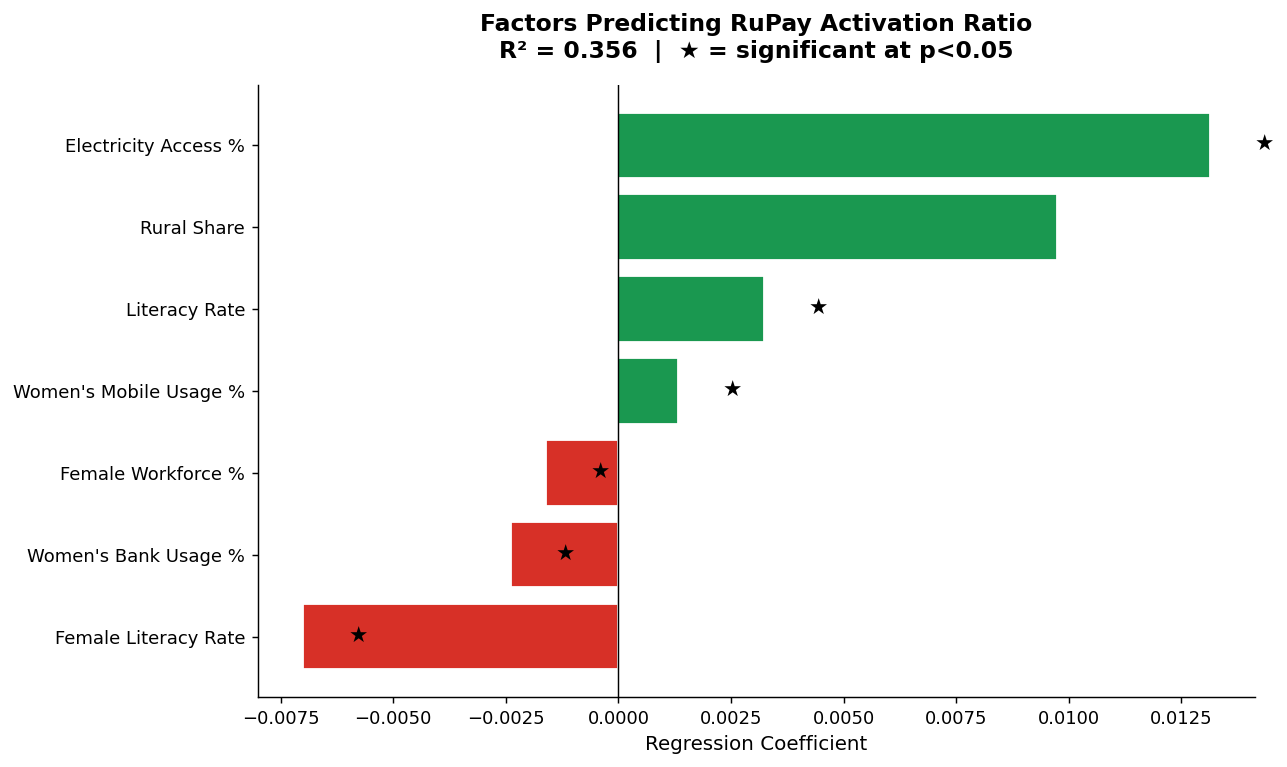

 R² = 0.356


In [8]:
#Coefficient plot 
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': model.params[1:].values,
    'pvalue':      model.pvalues[1:].values
}).sort_values('coefficient')

colors = ['#1a9850' if c > 0 else '#d73027' for c in coef_df['coefficient']]
sig    = ['★' if p < 0.05 else '' for p in coef_df['pvalue']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df['feature'], coef_df['coefficient'],
               color=colors, edgecolor='white')

for bar, s in zip(bars, sig):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            s, va='center', fontsize=12, color='black')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Regression Coefficient', fontsize=11)
ax.set_title(f'Factors Predicting RuPay Activation Ratio\n'
             f'R² = {model.rsquared:.3f}  |  ★ = significant at p<0.05',
             fontsize=13, fontweight='bold', pad=15)

feature_labels = {
    'literacy_rate':           'Literacy Rate',
    'female_literacy_rate':    'Female Literacy Rate',
    'rural_share':             'Rural Share',
    'female_workforce_pct':    'Female Workforce %',
    'women_bank_account_pct':  "Women's Bank Usage %",
    'electricity_access_pct':  'Electricity Access %',
    'women_mobile_pct':        "Women's Mobile Usage %",
}
ax.set_yticklabels([feature_labels.get(f, f) for f in coef_df['feature']])

plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm project\results\charts\08_regression_coefficients.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f" R² = {model.rsquared:.3f}")

In [9]:
#CLUSTERING
# Group states into High / Medium / Low inclusion


CLUSTER_FEATURES = [
    'rupay_activation_ratio',
    'avg_balance_per_account',
    'literacy_rate',
    'rural_share',
    'women_bank_account_pct',
]
CLUSTER_FEATURES = [f for f in CLUSTER_FEATURES if f in master.columns]

clust_df = master[CLUSTER_FEATURES + ['state_name']].dropna().copy()
print(f"States used in clustering: {len(clust_df)}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clust_df[CLUSTER_FEATURES])

States used in clustering: 726


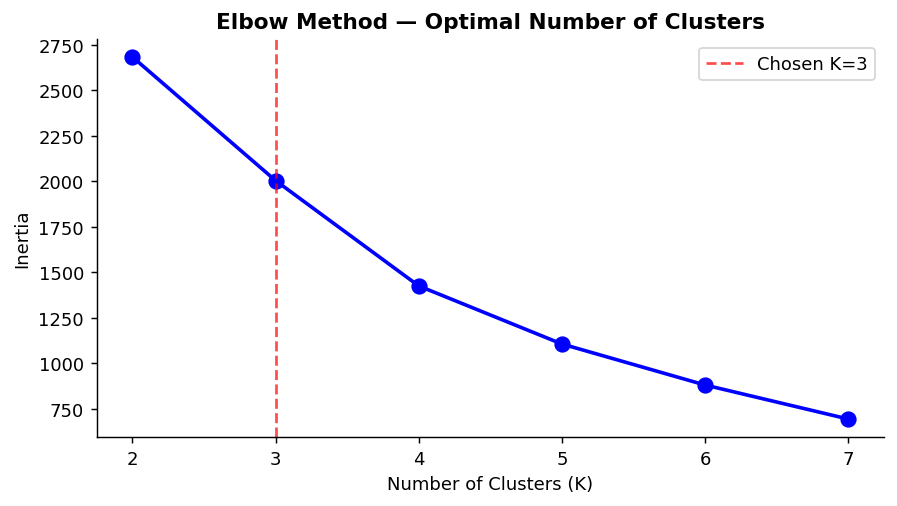

In [10]:
# elbow method finding k 
inertias = []
K_range  = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(3, color='red', linestyle='--', alpha=0.7, label='Chosen K=3')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm project\results\charts\09_elbow_plot.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Fit final K=3 model 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clust_df['cluster'] = kmeans.fit_predict(X_scaled)

# Label by mean RuPay activation ratio
cluster_means = clust_df.groupby('cluster')['rupay_activation_ratio'].mean().sort_values(ascending=False)
label_map     = {
    cluster_means.index[0]: 'High Inclusion',
    cluster_means.index[1]: 'Moderate Inclusion',
    cluster_means.index[2]: 'Low Inclusion (Dormancy Risk)',
}
clust_df['inclusion_category'] = clust_df['cluster'].map(label_map)

# Merge 
master = master.merge(
    clust_df[['state_name', 'cluster', 'inclusion_category']],
    on='state_name', how='left'
)

print("\nStates per cluster:")
print(clust_df.groupby('inclusion_category')['state_name'].apply(list))


States per cluster:
inclusion_category
High Inclusion                   [Delhi, Delhi, Delhi, Delhi, Delhi, Delhi, Del...
Low Inclusion (Dormancy Risk)    [Chandigarh, Chandigarh, Chandigarh, Chandigar...
Moderate Inclusion               [Andhra Pradesh, Andhra Pradesh, Andhra Prades...
Name: state_name, dtype: object


In [12]:
# Cluster profile table 
profile = clust_df.groupby('inclusion_category')[CLUSTER_FEATURES].mean().round(3)
print("\nCluster Profiles:")
print(profile.to_string())


Cluster Profiles:
                               rupay_activation_ratio  avg_balance_per_account  literacy_rate  rural_share  women_bank_account_pct
inclusion_category                                                                                                                
High Inclusion                                  0.777                 5474.815         75.046        0.091                  -6.250
Low Inclusion (Dormancy Risk)                   0.664                 7397.694         73.180        0.688                  81.321
Moderate Inclusion                              0.684                 4850.301         59.989        0.826                  78.393


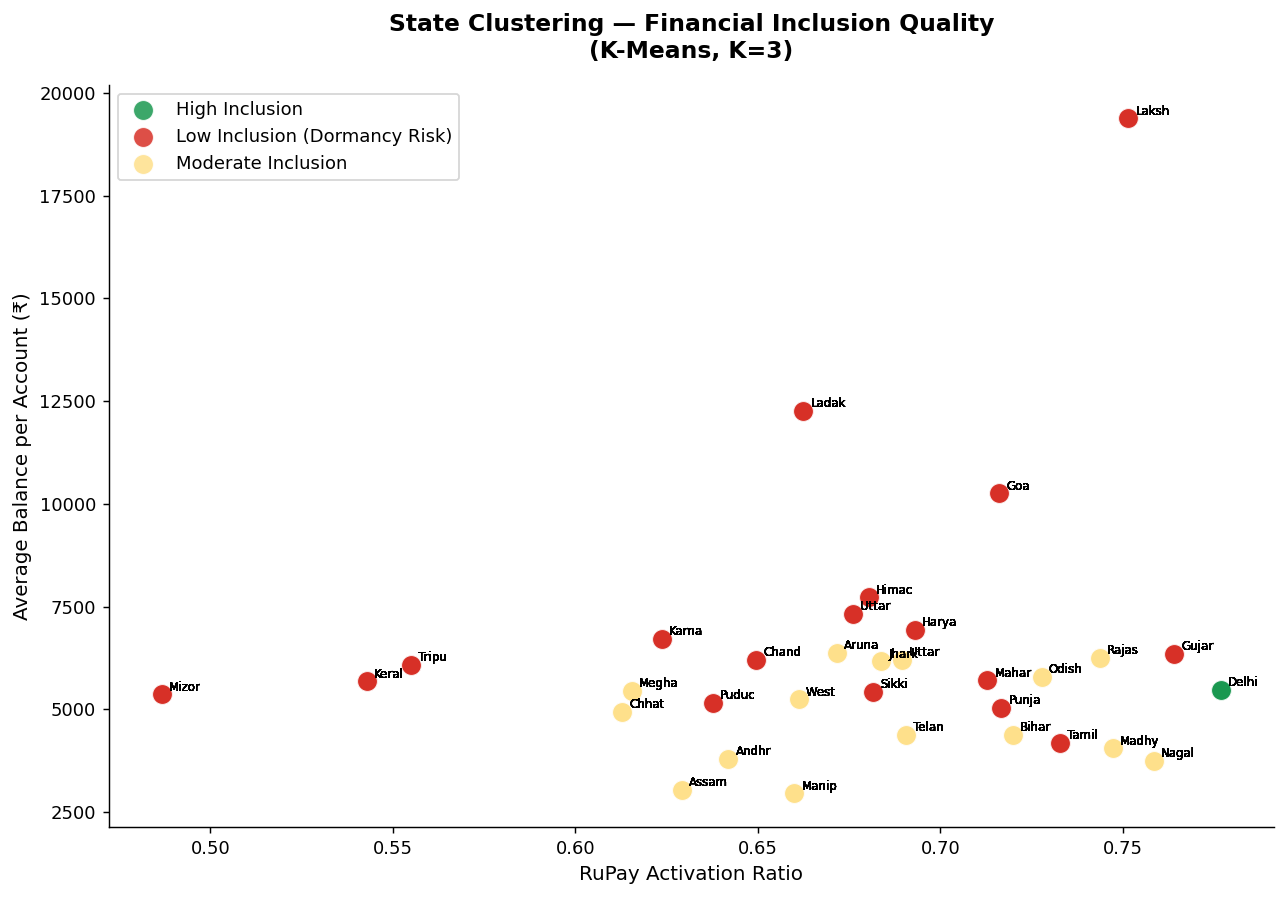

In [13]:
#Cluster visualization
colors_map = {
    'High Inclusion':              '#1a9850',
    'Moderate Inclusion':          '#fee08b',
    'Low Inclusion (Dormancy Risk)':'#d73027',
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat, grp in clust_df.groupby('inclusion_category'):
    ax.scatter(grp['rupay_activation_ratio'],
               grp['avg_balance_per_account'],
               label=cat, color=colors_map[cat],
               s=120, alpha=0.85, edgecolors='white', linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(str(row['state_name'])[:5],
                    (row['rupay_activation_ratio'], row['avg_balance_per_account']),
                    fontsize=6.5, alpha=0.75,
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('RuPay Activation Ratio', fontsize=11)
ax.set_ylabel('Average Balance per Account (₹)', fontsize=11)
ax.set_title('State Clustering — Financial Inclusion Quality\n(K-Means, K=3)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm project\results\charts\10_clusters.png",
            dpi=150, bbox_inches='tight')
plt.show()


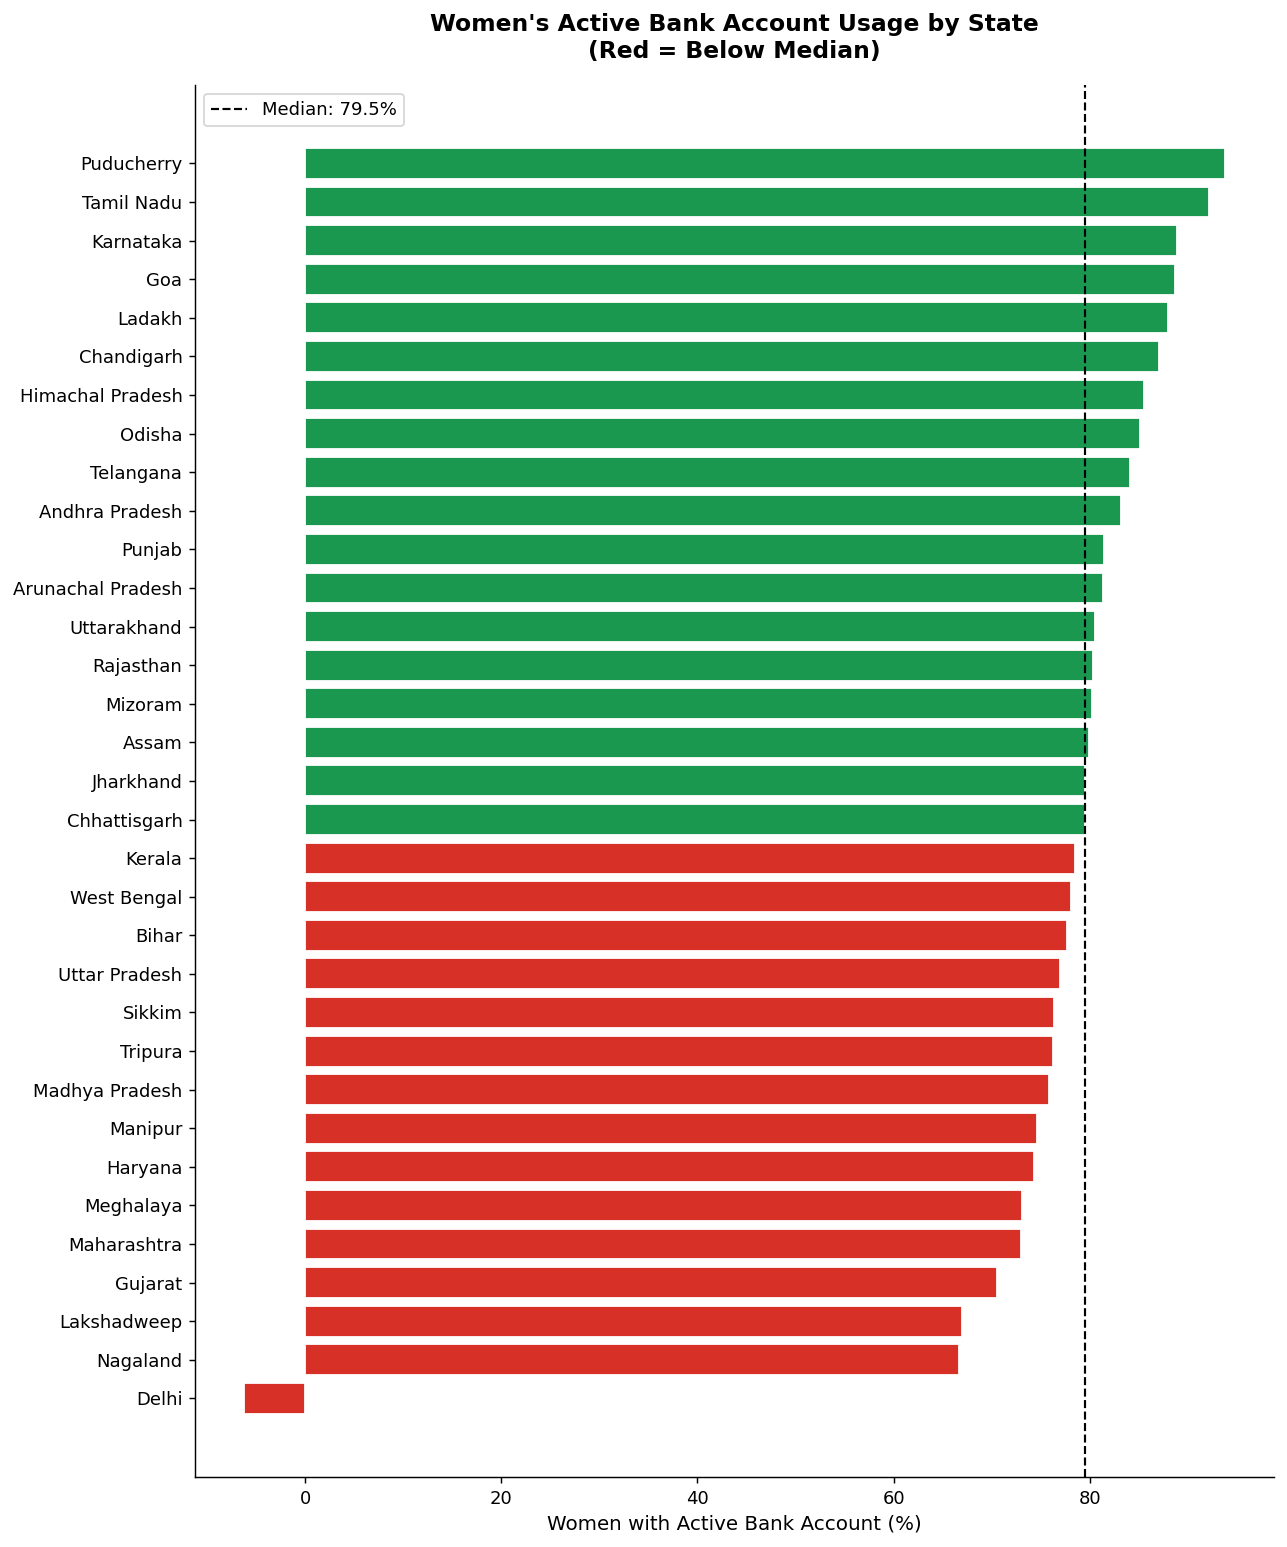

In [14]:
#GENDER ANALYSIS
# Women's bank usage % by state 
if 'women_bank_account_pct' in master.columns:
    df_g = master[['state_name', 'women_bank_account_pct',
                   'literacy_gender_gap']].dropna()
    df_g = df_g.sort_values('women_bank_account_pct', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 12))
    colors = ['#d73027' if x < df_g['women_bank_account_pct'].median()
              else '#1a9850' for x in df_g['women_bank_account_pct']]

    ax.barh(df_g['state_name'], df_g['women_bank_account_pct'],
            color=colors, edgecolor='white')
    ax.axvline(df_g['women_bank_account_pct'].median(),
               color='black', linestyle='--', linewidth=1.2,
               label=f"Median: {df_g['women_bank_account_pct'].median():.1f}%")
    ax.set_xlabel("Women with Active Bank Account (%)", fontsize=11)
    ax.set_title("Women's Active Bank Account Usage by State\n(Red = Below Median)",
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(r"C:\Users\Mihika\Desktop\dsm project\results\charts\11_women_bank_usage.png",
                dpi=150, bbox_inches='tight')
    plt.show()

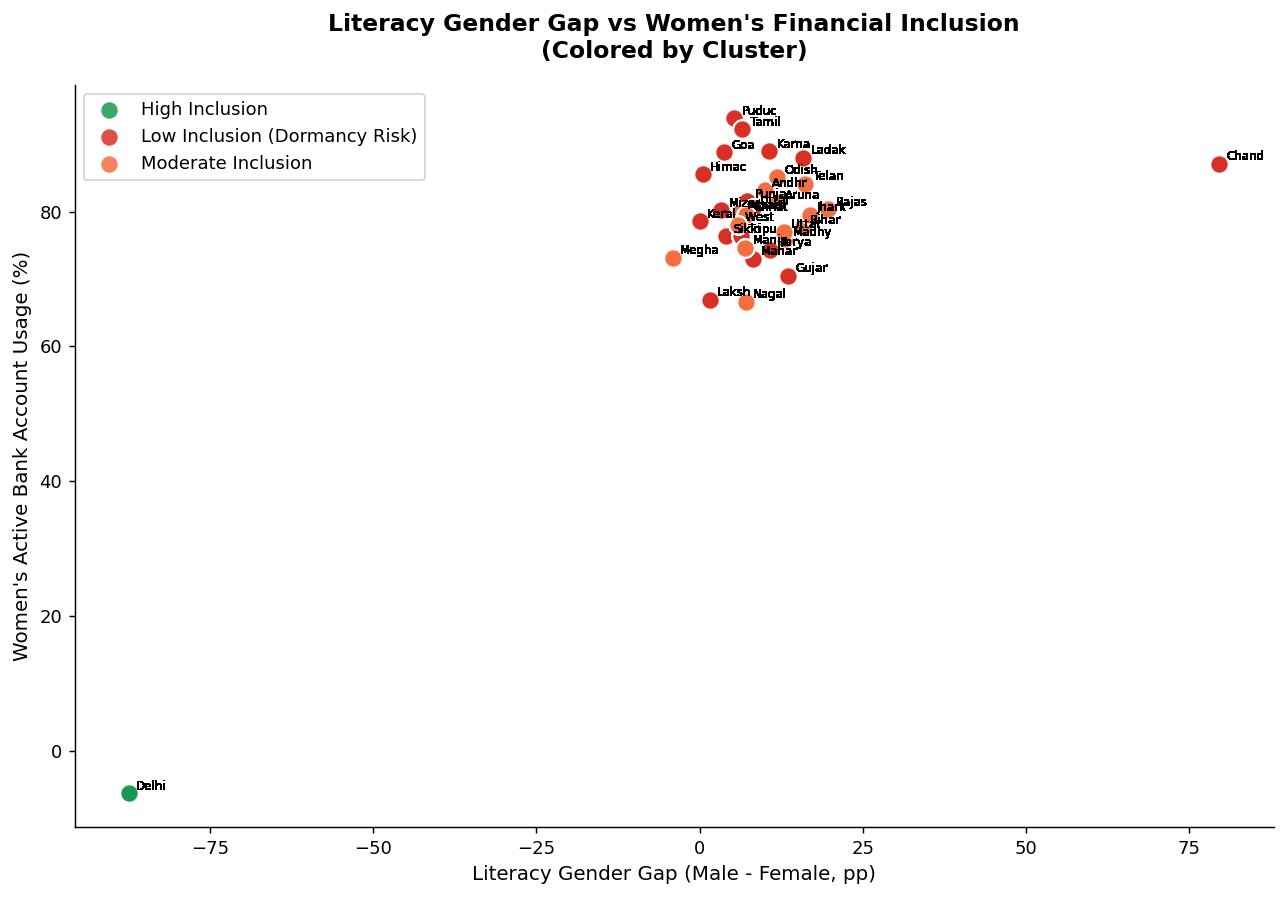

Gender analysis done


In [15]:
#Literacy gender gap vs Women's bank usage 
if all(c in master.columns for c in ['literacy_gender_gap', 'women_bank_account_pct']):
    clean = master[['state_name', 'literacy_gender_gap',
                    'women_bank_account_pct',
                    'inclusion_category']].dropna()

    colors_map2 = {
        'High Inclusion':               '#1a9850',
        'Moderate Inclusion':           '#f46d43',
        'Low Inclusion (Dormancy Risk)':'#d73027',
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    for cat, grp in clean.groupby('inclusion_category'):
        ax.scatter(grp['literacy_gender_gap'],
                   grp['women_bank_account_pct'],
                   label=cat,
                   color=colors_map2.get(cat, 'gray'),
                   s=100, alpha=0.85, edgecolors='white')
        for _, row in grp.iterrows():
            ax.annotate(str(row['state_name'])[:5],
                        (row['literacy_gender_gap'], row['women_bank_account_pct']),
                        fontsize=6.5, alpha=0.75,
                        xytext=(4, 2), textcoords='offset points')

    ax.set_xlabel('Literacy Gender Gap (Male - Female, pp)', fontsize=11)
    ax.set_ylabel("Women's Active Bank Account Usage (%)", fontsize=11)
    ax.set_title("Literacy Gender Gap vs Women's Financial Inclusion\n(Colored by Cluster)",
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(r"C:\Users\Mihika\Desktop\dsm project\results\charts\12_gender_gap_vs_inclusion.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Gender analysis done")

In [16]:
# SQL QUERIES 

conn = sqlite3.connect("/Users/mrinalini/Desktop/dsm project/database/pmjdy.db")

queries = {
    "Top 10 states by RuPay activation": """
        SELECT p.state_name,
               ROUND(p.rupay_activation_ratio, 3) AS rupay_ratio,
               ROUND(p.avg_balance_per_account, 2) AS avg_balance,
               ROUND(c.literacy_rate, 1) AS literacy_rate
        FROM pmjdy_accounts p
        LEFT JOIN census_2011 c ON p.state_name = c.state_name
        ORDER BY p.rupay_activation_ratio DESC
        LIMIT 10;
    """,
    "States with lowest women bank usage": """
        SELECT p.state_name,
               ROUND(n.women_bank_account_pct, 1) AS women_bank_pct,
               ROUND(p.rupay_activation_ratio, 3) AS rupay_ratio,
               ROUND(n.literacy_gender_gap, 1) AS gender_gap
        FROM pmjdy_accounts p
        LEFT JOIN nfhs_state n ON p.state_name = n.state_name
        WHERE n.women_bank_account_pct IS NOT NULL
        ORDER BY n.women_bank_account_pct ASC
        LIMIT 10;
    """,
    "Rural vs Urban account distribution": """
        SELECT state_name,
               ROUND(rural_accounts * 1.0 / total_accounts, 3) AS rural_share,
               ROUND(urban_accounts * 1.0 / total_accounts, 3) AS urban_share,
               total_accounts
        FROM pmjdy_accounts
        ORDER BY rural_share DESC;
    """,
}

for title, query in queries.items():
    print(f"\n{'='*55}")
    print(f"  {title}")
    print('='*55)
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))

conn.close()


  Top 10 states by RuPay activation
                                  state_name  rupay_ratio  avg_balance  literacy_rate
                                       Delhi        0.777      5474.81           75.0
                                     Gujarat        0.764      6347.85           68.0
                                    Nagaland        0.758      3746.90           67.9
                                 Lakshadweep        0.752     19380.21           81.5
                              Madhya Pradesh        0.747      4046.77           59.0
                                   Rajasthan        0.744      6254.55           55.8
                                  Tamil Nadu        0.733      4184.61           71.8
                                      Odisha        0.728      5789.88           63.7
The Dadra And Nagar Haveli And Daman And Diu        0.721      7991.86           70.1
                                       Bihar        0.720      4383.38           50.4

  States with lo